In [1]:
import pandas as pd
data = pd.read_csv('/home/ijain/Clean_parflex/runtime_results/runtime_trials.csv')
data.head()


,system,P,L,trial,runtime_sec,distance
0,Parflex_CPU_notebook,10000,6000,1,12.381443,0.307293
1,Parflex_GPU,10000,6000,1,5.084608,0.307293
2,Parflex_CPU_notebook,10000,6000,2,4.822448,0.307293
3,Parflex_GPU,10000,6000,2,3.959746,0.307293
4,Parflex_CPU_notebook,10000,6000,3,4.816057,0.307293


In [2]:
data

,system,P,L,trial,runtime_sec,distance
0,Parflex_CPU_notebook,10000,6000,1,12.381443,0.307293
1,Parflex_GPU,10000,6000,1,5.084608,0.307293
2,Parflex_CPU_notebook,10000,6000,2,4.822448,0.307293
3,Parflex_GPU,10000,6000,2,3.959746,0.307293
4,Parflex_CPU_notebook,10000,6000,3,4.816057,0.307293
...,...,...,...,...,...,...
96,Parflex_CPU_notebook,80000,6000,9,225.415591,0.303213
97,Parflex_GPU,80000,6000,9,190.272920,0.149966
98,Parflex_CPU_notebook,80000,6000,10,222.622510,0.303213
99,Parflex_GPU,80000,6000,10,193.443541,0.149966


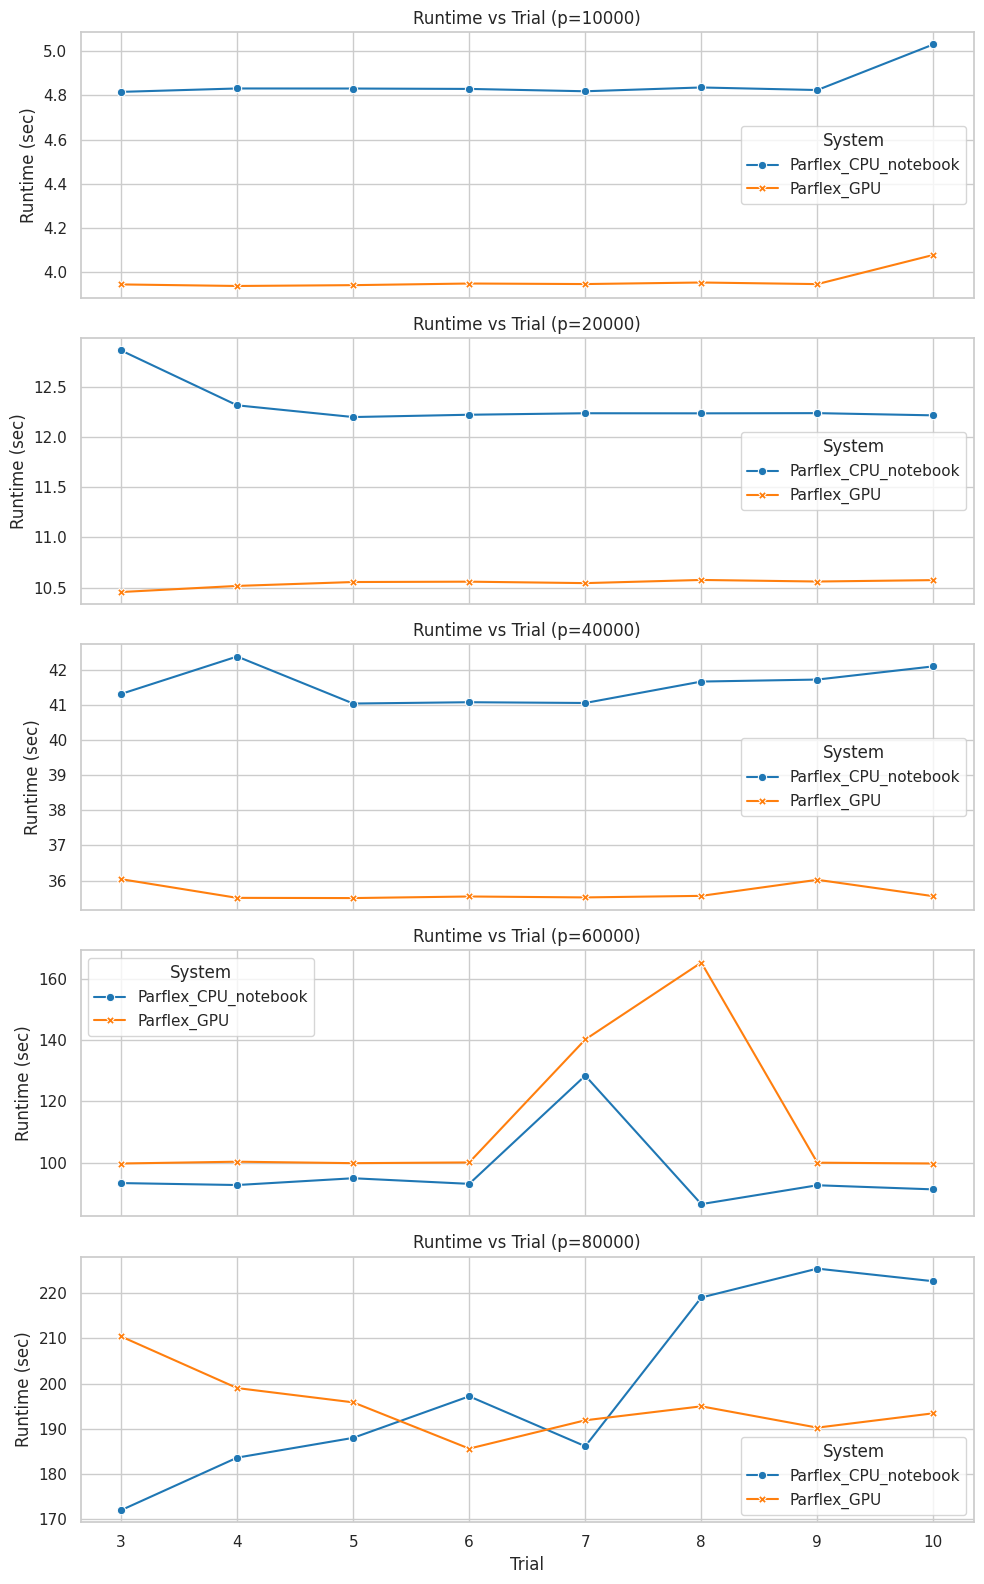

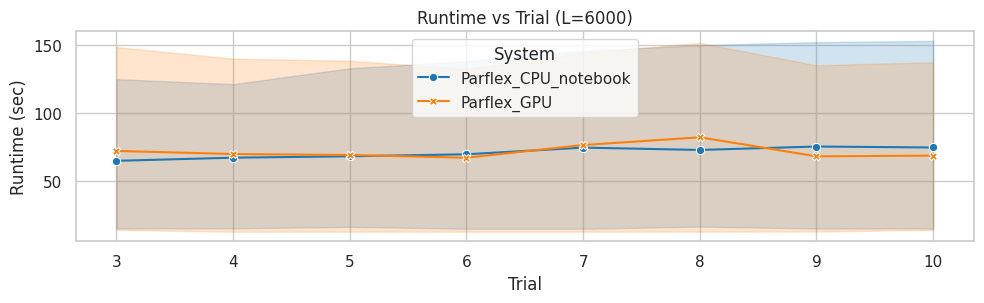

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

# Keep names consistent for plotting
df = data.copy()
df = df.rename(columns={'P': 'p', 'L': 'L', 'trial': 'trial'})

# Stable colors by system
systems = sorted(df['system'].unique())
palette = {
    systems[0]: '#1f77b4',
    systems[1]: '#ff7f0e'
} if len(systems) >= 2 else None
# remove the first trial for both cpu and gpu
df = df[df['trial'] != 0]
df = df[df['trial'] != 1]
df = df[df['trial'] != 2]
# 1) Runtime across trials, shown separately for each p value
p_values = sorted(df['p'].unique())
fig, axes = plt.subplots(
    nrows=len(p_values), ncols=1,
    figsize=(10, 3.2 * len(p_values)),
    sharex=True
)
if len(p_values) == 1:
    axes = [axes]

for ax, p_val in zip(axes, p_values):
    sub = df[df['p'] == p_val]
    sns.lineplot(
        data=sub,
        x='trial', y='runtime_sec',
        hue='system', style='system',
        markers=True, dashes=False,
        palette=palette,
        ax=ax
    )
    ax.set_title(f'Runtime vs Trial (p={p_val})')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Runtime (sec)')
    ax.legend(title='System')

plt.tight_layout()
plt.show()

# 2) Runtime across trials, shown separately for each L value
L_values = sorted(df['L'].unique())
fig, axes = plt.subplots(
    nrows=len(L_values), ncols=1,
    figsize=(10, 3.2 * len(L_values)),
    sharex=True
)
if len(L_values) == 1:
    axes = [axes]

for ax, L_val in zip(axes, L_values):
    sub = df[df['L'] == L_val]
    sns.lineplot(
        data=sub,
        x='trial', y='runtime_sec',
        hue='system', style='system',
        markers=True, dashes=False,
        palette=palette,
        ax=ax
    )
    ax.set_title(f'Runtime vs Trial (L={L_val})')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Runtime (sec)')
    ax.legend(title='System')

plt.tight_layout()
plt.show()

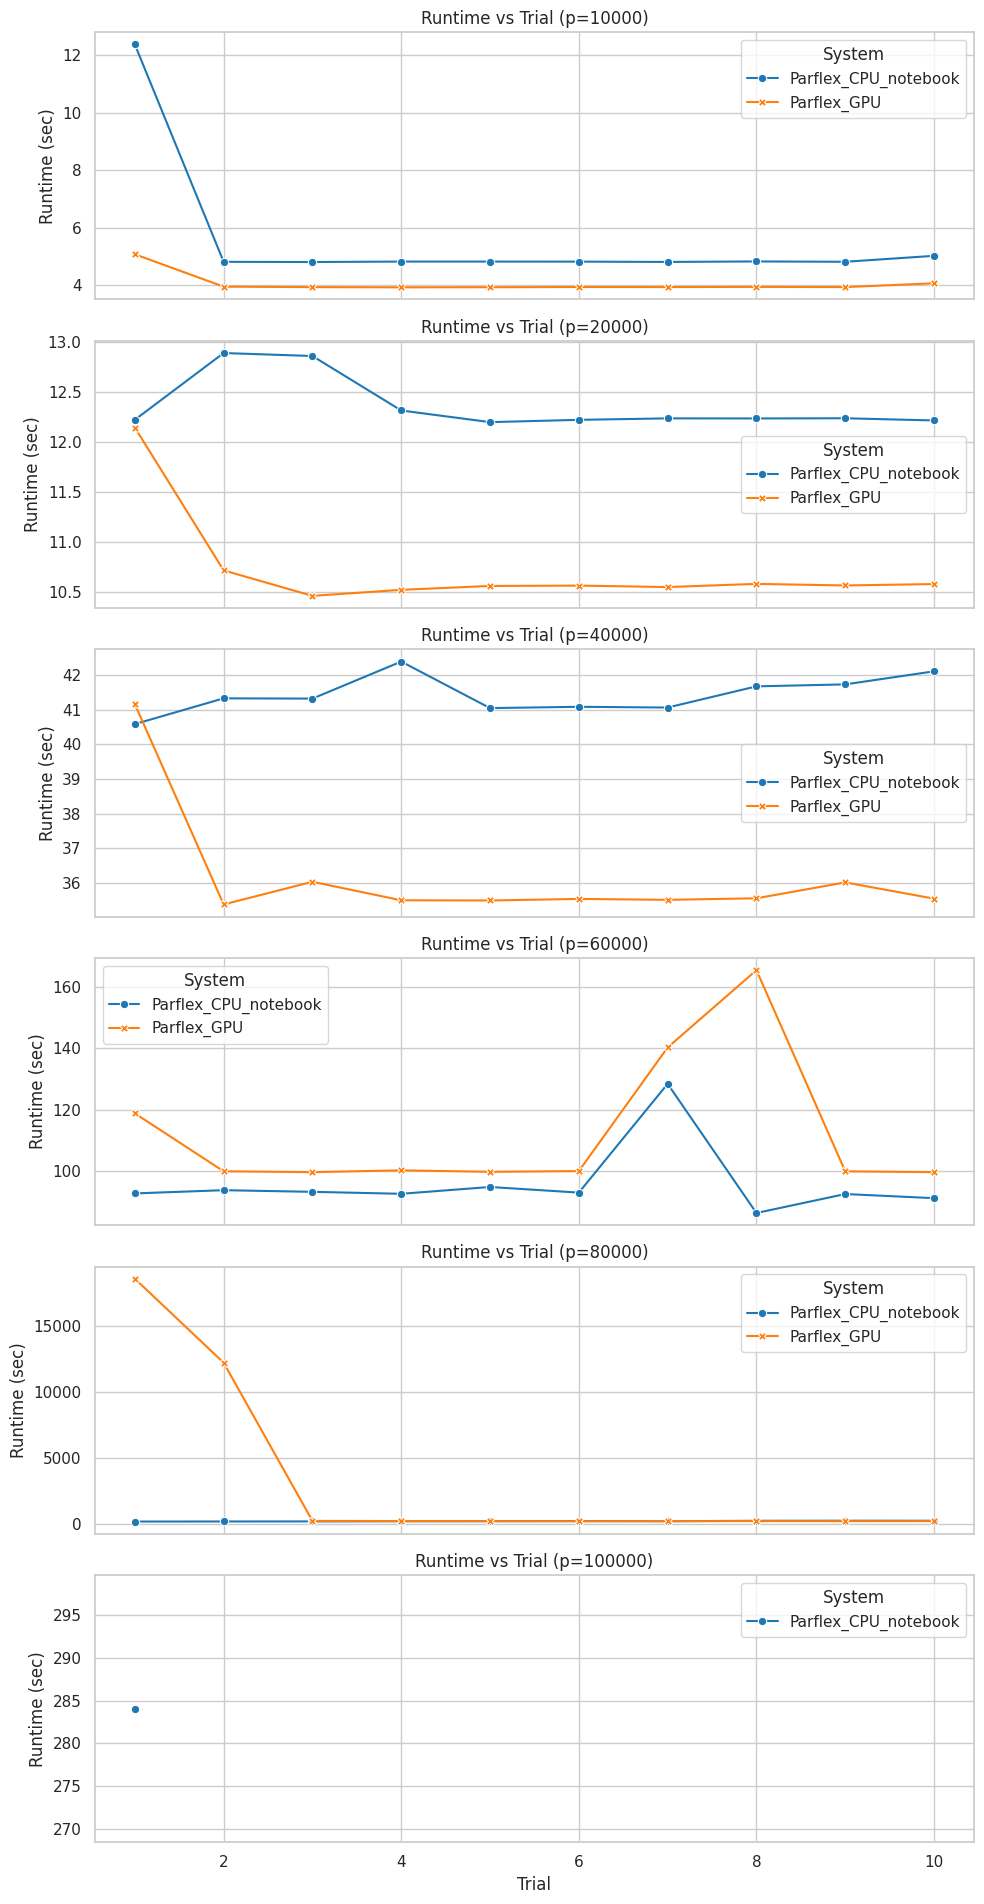

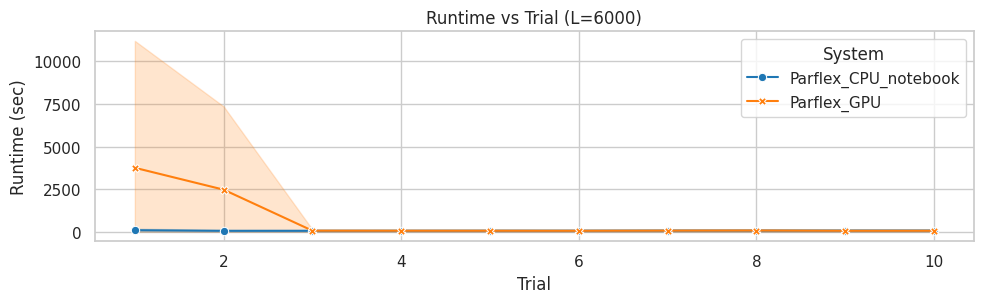

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

# Keep names consistent for plotting
df = data.copy()
df = df.rename(columns={'P': 'p', 'L': 'L', 'trial': 'trial'})

# Stable colors by system
systems = sorted(df['system'].unique())
palette = {
    systems[0]: '#1f77b4',
    systems[1]: '#ff7f0e'
} if len(systems) >= 2 else None

# 1) Runtime across trials, shown separately for each p value
p_values = sorted(df['p'].unique())
fig, axes = plt.subplots(
    nrows=len(p_values), ncols=1,
    figsize=(10, 3.2 * len(p_values)),
    sharex=True
)
if len(p_values) == 1:
    axes = [axes]

for ax, p_val in zip(axes, p_values):
    sub = df[df['p'] == p_val]
    sns.lineplot(
        data=sub,
        x='trial', y='runtime_sec',
        hue='system', style='system',
        markers=True, dashes=False,
        palette=palette,
        ax=ax
    )
    ax.set_title(f'Runtime vs Trial (p={p_val})')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Runtime (sec)')
    ax.legend(title='System')

plt.tight_layout()
plt.show()

# 2) Runtime across trials, shown separately for each L value
L_values = sorted(df['L'].unique())
fig, axes = plt.subplots(
    nrows=len(L_values), ncols=1,
    figsize=(10, 3.2 * len(L_values)),
    sharex=True
)
if len(L_values) == 1:
    axes = [axes]

for ax, L_val in zip(axes, L_values):
    sub = df[df['L'] == L_val]
    sns.lineplot(
        data=sub,
        x='trial', y='runtime_sec',
        hue='system', style='system',
        markers=True, dashes=False,
        palette=palette,
        ax=ax
    )
    ax.set_title(f'Runtime vs Trial (L={L_val})')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Runtime (sec)')
    ax.legend(title='System')

plt.tight_layout()
plt.show()

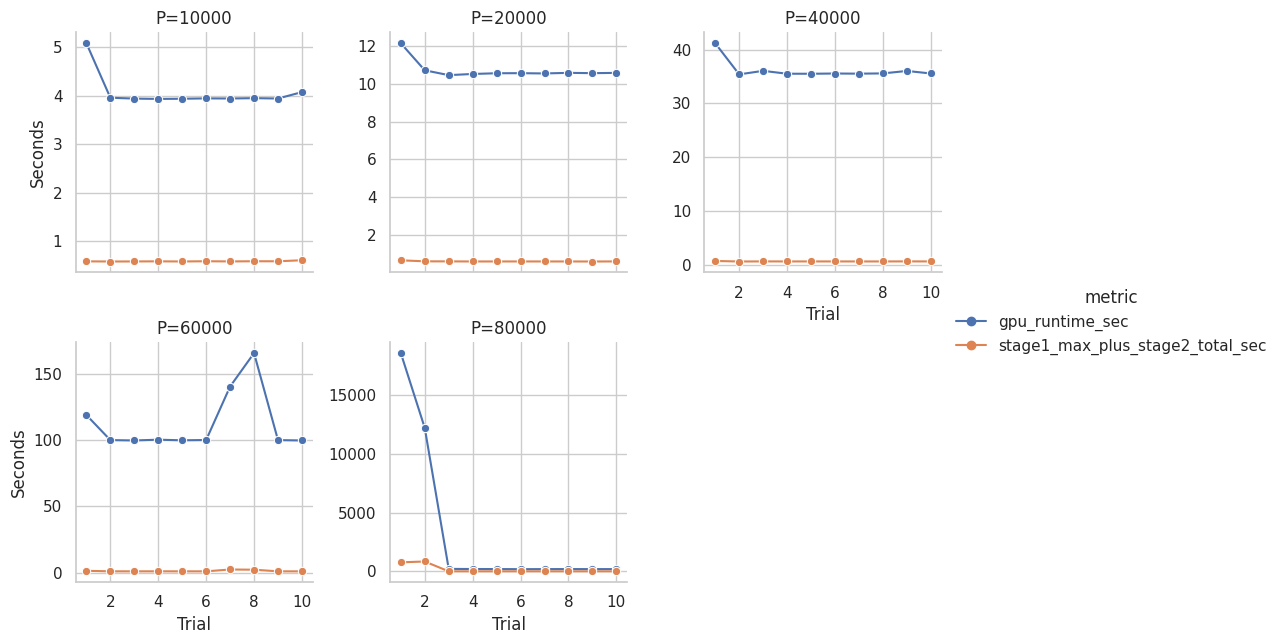

Per-trial comparison (first 12 rows):


,P,L,trial,gpu_runtime_sec,stage1_max_chunk_sec,stage2_total_sec,stage1_max_plus_stage2_total_sec,delta_sec,ratio_gpu_over_proxy
0,10000,6000,1,5.084608,0.443290,0.141190,0.584480,4.500128,8.699374
1,10000,6000,2,3.959746,0.444632,0.136788,0.581420,3.378326,6.810474
2,10000,6000,3,3.942751,0.444153,0.138494,0.582647,3.360105,6.766969
3,10000,6000,4,3.935728,0.444279,0.140486,0.584765,3.350964,6.730447
4,10000,6000,5,3.939451,0.444231,0.137897,0.582128,3.357323,6.767330
5,10000,6000,6,3.946864,0.444514,0.142129,0.586643,3.360221,6.727880
6,10000,6000,7,3.944454,0.444408,0.138662,0.583070,3.361383,6.764969
7,10000,6000,8,3.951470,0.444699,0.141758,0.586457,3.365013,6.737871
8,10000,6000,9,3.944229,0.444580,0.141336,0.585916,3.358313,6.731727
9,10000,6000,10,4.076619,0.469878,0.137606,0.607484,3.469135,6.710662



Aggregated summary:


,P,L,mean_gpu_runtime_sec,mean_parallel_proxy_sec,mean_delta_sec,mean_ratio_gpu_over_proxy,n_trials
0,10000,6000,4.072592,0.586501,3.486091,6.944770,10
1,20000,6000,10.720775,0.612866,10.107908,17.485803,10
2,40000,6000,36.180018,0.658171,35.521847,54.960256,10
3,60000,6000,112.406270,1.477406,110.928863,79.330712,10
4,80000,6000,3237.604630,162.287354,3075.317276,99.782826,10


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

runtime_trials_path = Path('/home/ijain/Clean_parflex/runtime_results/runtime_trials.csv')
profile_root = Path('/home/ijain/Clean_parflex/runtime_results/results_profiling')

trials_df = pd.read_csv(runtime_trials_path)
gpu_trials = (
    trials_df.loc[trials_df['system'] == 'Parflex_GPU', ['P', 'L', 'trial', 'runtime_sec']]
    .copy()
    .sort_values(['P', 'L', 'trial'])
)

def _read_stage1_max_chunk(profile_dir: Path) -> float:
    p = profile_dir / 'chunk_flexdtw.csv'
    if not p.exists():
        return np.nan
    df = pd.read_csv(p)
    if 'elapsed_seconds' not in df.columns:
        return np.nan
    # Exclude optional warmup row from Stage-1 parallel-chunk timing.
    if 'chunk_i' in df.columns:
        df = df[df['chunk_i'].astype(str) != 'warmup']
    if df.empty:
        return np.nan
    return pd.to_numeric(df['elapsed_seconds'], errors='coerce').max()

def _read_stage2_total(profile_dir: Path) -> float:
    p = profile_dir / 'parflex_end_to_end_phases.csv'
    if not p.exists():
        return np.nan
    df = pd.read_csv(p)
    if not {'phase', 'elapsed_seconds'}.issubset(df.columns):
        return np.nan
    s2 = df.loc[df['phase'] == 'stage2_scan_and_stitch_total', 'elapsed_seconds']
    if s2.empty:
        return np.nan
    return pd.to_numeric(s2, errors='coerce').sum()

rows = []
for _, r in gpu_trials.iterrows():
    p = int(r['P'])
    l = int(r['L'])
    t = int(r['trial'])
    trial_dir = profile_root / f'parflex_gpu_P{p}_L{l}_trial{t}'

    stage1_max = _read_stage1_max_chunk(trial_dir)
    stage2_total = _read_stage2_total(trial_dir)
    parallel_proxy = stage1_max + stage2_total if pd.notna(stage1_max) and pd.notna(stage2_total) else np.nan

    rows.append({
        'P': p,
        'L': l,
        'trial': t,
        'gpu_runtime_sec': float(r['runtime_sec']),
        'stage1_max_chunk_sec': stage1_max,
        'stage2_total_sec': stage2_total,
        'stage1_max_plus_stage2_total_sec': parallel_proxy,
    })

compare_df = pd.DataFrame(rows).sort_values(['P', 'L', 'trial'])
compare_df['delta_sec'] = compare_df['gpu_runtime_sec'] - compare_df['stage1_max_plus_stage2_total_sec']
compare_df['ratio_gpu_over_proxy'] = compare_df['gpu_runtime_sec'] / compare_df['stage1_max_plus_stage2_total_sec']

long_df = compare_df.melt(
    id_vars=['P', 'L', 'trial'],
    value_vars=['gpu_runtime_sec', 'stage1_max_plus_stage2_total_sec'],
    var_name='metric',
    value_name='seconds',
)

sns.set_theme(style='whitegrid')
g = sns.relplot(
    data=long_df,
    x='trial',
    y='seconds',
    hue='metric',
    col='P',
    kind='line',
    marker='o',
    col_wrap=3,
    height=3.3,
    facet_kws={'sharey': False},
)
g.set_axis_labels('Trial', 'Seconds')
g.set_titles('P={col_name}')
plt.show()

summary = (
    compare_df.groupby(['P', 'L'], as_index=False)
    .agg(
        mean_gpu_runtime_sec=('gpu_runtime_sec', 'mean'),
        mean_parallel_proxy_sec=('stage1_max_plus_stage2_total_sec', 'mean'),
        mean_delta_sec=('delta_sec', 'mean'),
        mean_ratio_gpu_over_proxy=('ratio_gpu_over_proxy', 'mean'),
        n_trials=('trial', 'count'),
    )
    .sort_values(['P', 'L'])
)

print('Per-trial comparison (first 12 rows):')
display(compare_df.head(12))
print('\nAggregated summary:')
display(summary)

missing_profiles = compare_df[compare_df['stage1_max_plus_stage2_total_sec'].isna()][['P', 'L', 'trial']]
if not missing_profiles.empty:
    print('\nWarning: missing profiling files for these trials:')
    display(missing_profiles)


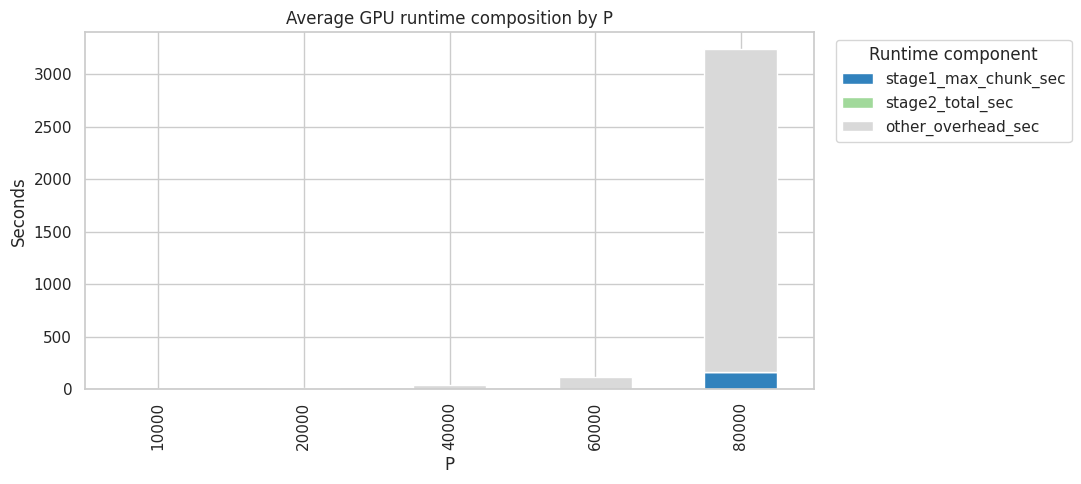

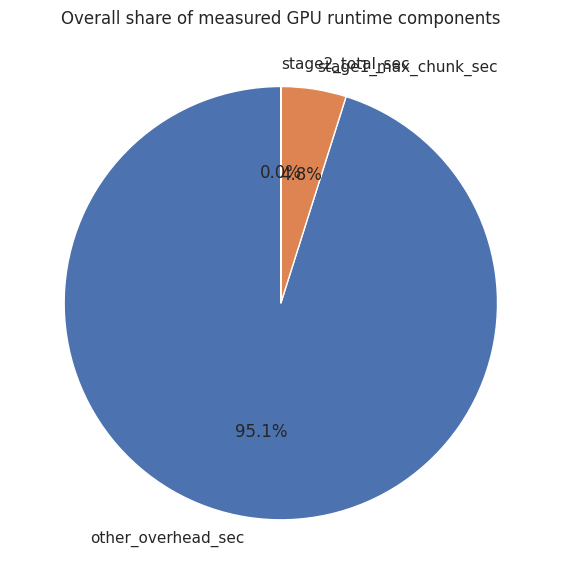

Overall runtime share by component (%):


,percent
other_overhead_sec,95.13
stage1_max_chunk_sec,4.84
stage2_total_sec,0.03


In [6]:
# Runtime contribution breakdown: where most GPU runtime goes
phase_df = compare_df[['P', 'L', 'trial', 'gpu_runtime_sec', 'stage1_max_chunk_sec', 'stage2_total_sec']].copy()
phase_df = phase_df.dropna(subset=['gpu_runtime_sec', 'stage1_max_chunk_sec', 'stage2_total_sec'])

phase_df['other_overhead_sec'] = (
    phase_df['gpu_runtime_sec'] - phase_df['stage1_max_chunk_sec'] - phase_df['stage2_total_sec']
).clip(lower=0)

phase_summary = (
    phase_df.groupby('P', as_index=False)
    .agg(
        stage1_max_chunk_sec=('stage1_max_chunk_sec', 'mean'),
        stage2_total_sec=('stage2_total_sec', 'mean'),
        other_overhead_sec=('other_overhead_sec', 'mean'),
        gpu_runtime_sec=('gpu_runtime_sec', 'mean'),
    )
)

stack_cols = ['stage1_max_chunk_sec', 'stage2_total_sec', 'other_overhead_sec']
plot_df = phase_summary.set_index('P')[stack_cols]

ax = plot_df.plot(kind='bar', stacked=True, figsize=(11, 5), colormap='tab20c')
ax.set_title('Average GPU runtime composition by P')
ax.set_xlabel('P')
ax.set_ylabel('Seconds')
ax.legend(title='Runtime component', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

overall = plot_df.sum()
overall_pct = (overall / overall.sum() * 100).sort_values(ascending=False)

plt.figure(figsize=(6, 6))
plt.pie(overall_pct.values, labels=overall_pct.index, autopct='%1.1f%%', startangle=90)
plt.title('Overall share of measured GPU runtime components')
plt.tight_layout()
plt.show()

print('Overall runtime share by component (%):')
display(overall_pct.rename('percent').round(2).to_frame())

Top GPU phases by mean elapsed seconds:


,phase,mean_elapsed_sec,total_elapsed_sec,mean_pct_of_gpu_runtime,n_obs
3,stage1_chunk_flexdtw_all_tiles,616.984034,30849.201699,71.832505,50
2,propagate_tile_edge_costs_total,60.408176,3020.408800,21.526503,50
1,gpu_host_to_device_C,1.828424,91.421209,2.472945,50
4,stage2_scan_and_stitch_total,0.227113,11.355673,1.169939,50
0,build_tiled_metadata,0.000684,0.034203,0.000902,50
5,sync_tile_overlap_edges,0.000045,0.002274,0.000227,50


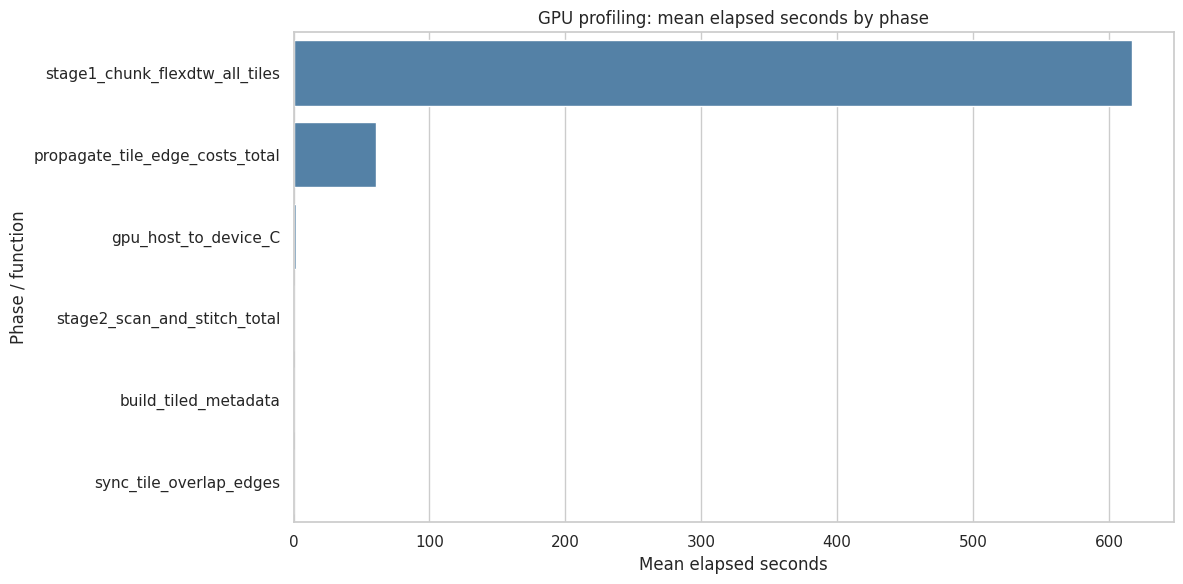

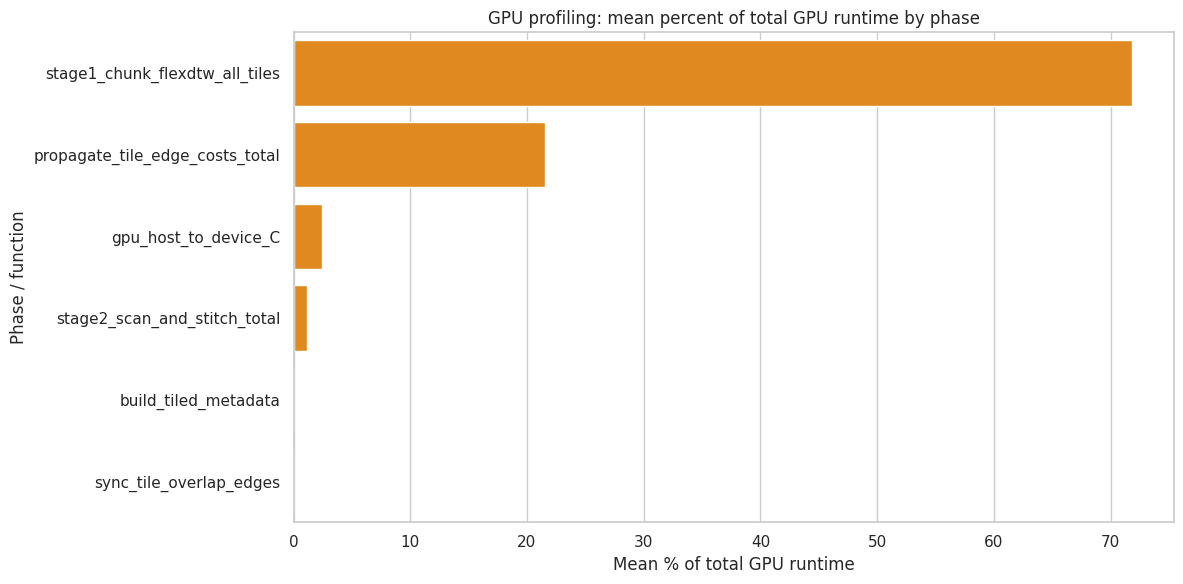

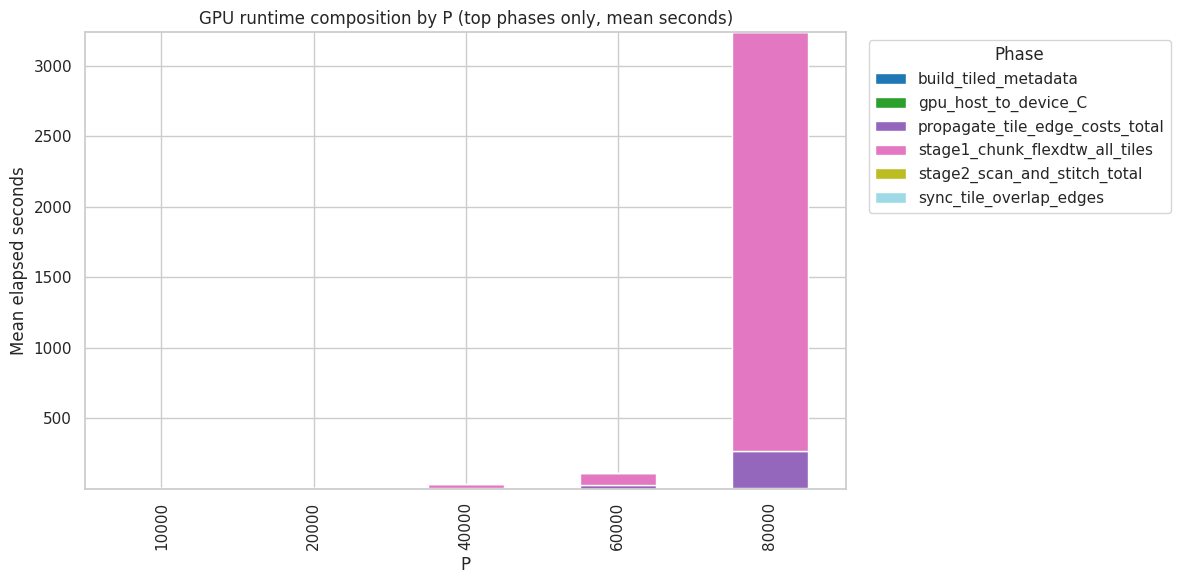

In [7]:
# Detailed GPU function-level runtime breakdown
phase_rows = []
for _, r in gpu_trials.iterrows():
    p = int(r['P'])
    l = int(r['L'])
    t = int(r['trial'])
    runtime_sec = float(r['runtime_sec'])

    trial_dir = profile_root / f'parflex_gpu_P{p}_L{l}_trial{t}'
    phase_csv = trial_dir / 'parflex_end_to_end_phases.csv'
    if not phase_csv.exists():
        continue

    phase_trial = pd.read_csv(phase_csv)
    if not {'phase', 'elapsed_seconds'}.issubset(phase_trial.columns):
        continue

    phase_trial = phase_trial[['phase', 'elapsed_seconds']].copy()
    phase_trial['elapsed_seconds'] = pd.to_numeric(phase_trial['elapsed_seconds'], errors='coerce')
    phase_trial = phase_trial.dropna(subset=['elapsed_seconds'])

    phase_trial['P'] = p
    phase_trial['L'] = l
    phase_trial['trial'] = t
    phase_trial['gpu_runtime_sec'] = runtime_sec
    phase_trial['phase_pct_of_gpu_runtime'] = 100.0 * phase_trial['elapsed_seconds'] / runtime_sec
    phase_rows.append(phase_trial)

phase_long_df = pd.concat(phase_rows, ignore_index=True)

phase_summary = (
    phase_long_df.groupby('phase', as_index=False)
    .agg(
        mean_elapsed_sec=('elapsed_seconds', 'mean'),
        total_elapsed_sec=('elapsed_seconds', 'sum'),
        mean_pct_of_gpu_runtime=('phase_pct_of_gpu_runtime', 'mean'),
        n_obs=('elapsed_seconds', 'count'),
    )
    .sort_values('mean_elapsed_sec', ascending=False)
)

print('Top GPU phases by mean elapsed seconds:')
display(phase_summary.head(20))

plt.figure(figsize=(12, 6))
sns.barplot(
    data=phase_summary,
    x='mean_elapsed_sec',
    y='phase',
    order=phase_summary['phase'],
    color='steelblue',
)
plt.title('GPU profiling: mean elapsed seconds by phase')
plt.xlabel('Mean elapsed seconds')
plt.ylabel('Phase / function')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=phase_summary,
    x='mean_pct_of_gpu_runtime',
    y='phase',
    order=phase_summary['phase'],
    color='darkorange',
)
plt.title('GPU profiling: mean percent of total GPU runtime by phase')
plt.xlabel('Mean % of total GPU runtime')
plt.ylabel('Phase / function')
plt.tight_layout()
plt.show()

# Optional: composition by P for the most expensive phases.
top_phases = phase_summary.head(8)['phase'].tolist()
phase_by_p = (
    phase_long_df[phase_long_df['phase'].isin(top_phases)]
    .groupby(['P', 'phase'], as_index=False)['elapsed_seconds']
    .mean()
)
phase_pivot = phase_by_p.pivot(index='P', columns='phase', values='elapsed_seconds').fillna(0)

ax = phase_pivot.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
ax.set_title('GPU runtime composition by P (top phases only, mean seconds)')
ax.set_xlabel('P')
ax.set_ylabel('Mean elapsed seconds')
ax.legend(title='Phase', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

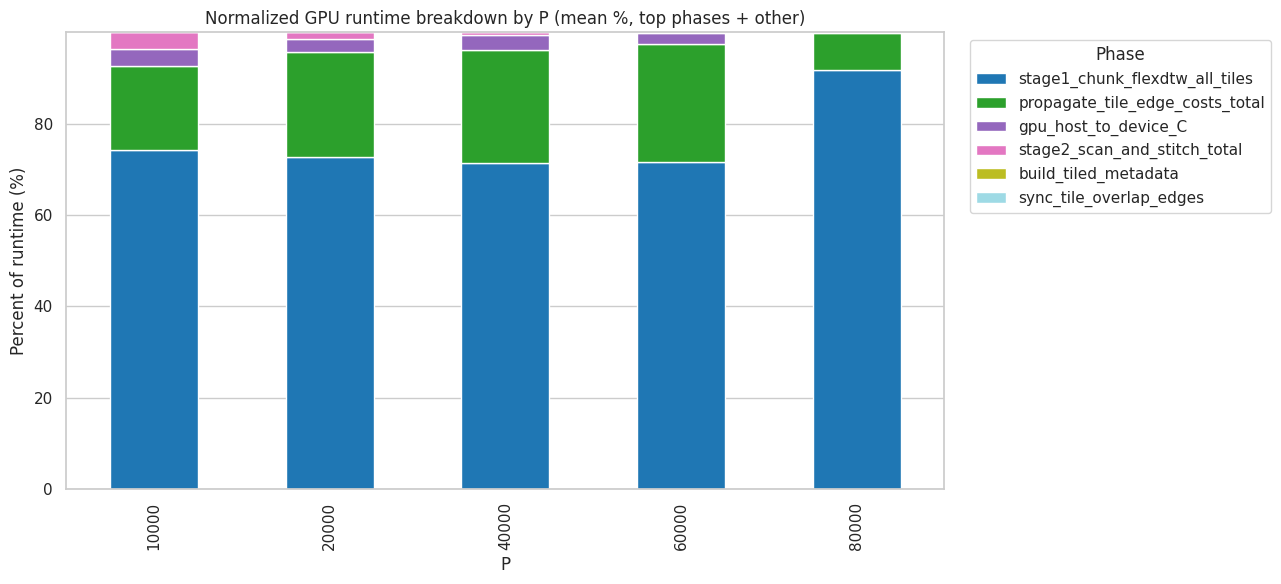

Top 3 runtime contributors per P (%):


,P,phase,pct
0,10000,stage1_chunk_flexdtw_all_tiles,74.24
5,10000,propagate_tile_edge_costs_total,18.40
15,10000,stage2_scan_and_stitch_total,3.75
1,20000,stage1_chunk_flexdtw_all_tiles,72.68
6,20000,propagate_tile_edge_costs_total,22.95
11,20000,gpu_host_to_device_C,2.84
2,40000,stage1_chunk_flexdtw_all_tiles,71.31
7,40000,propagate_tile_edge_costs_total,24.86
12,40000,gpu_host_to_device_C,3.29
3,60000,stage1_chunk_flexdtw_all_tiles,71.50


In [8]:
# Normalized runtime composition per P (each P sums to 100%)
# Uses phase_long_df from the detailed GPU breakdown cell.

if 'phase_long_df' not in globals() or phase_long_df.empty:
    raise ValueError('Run the detailed GPU function-level runtime breakdown cell first.')

# Mean phase time per P, then normalize within each P.
phase_by_p = (
    phase_long_df.groupby(['P', 'phase'], as_index=False)['elapsed_seconds']
    .mean()
)

# Keep only the top phases globally for readability.
global_phase_totals = (
    phase_by_p.groupby('phase', as_index=False)['elapsed_seconds']
    .sum()
    .sort_values('elapsed_seconds', ascending=False)
)
keep_top_n = 10
top_phases = global_phase_totals.head(keep_top_n)['phase'].tolist()

phase_by_p_top = phase_by_p[phase_by_p['phase'].isin(top_phases)].copy()
other_by_p = (
    phase_by_p[~phase_by_p['phase'].isin(top_phases)]
    .groupby('P', as_index=False)['elapsed_seconds']
    .sum()
    .assign(phase='other')
)
plot_phase_by_p = pd.concat([phase_by_p_top, other_by_p], ignore_index=True)

pivot_sec = plot_phase_by_p.pivot(index='P', columns='phase', values='elapsed_seconds').fillna(0)
pivot_pct = pivot_sec.div(pivot_sec.sum(axis=1), axis=0) * 100

# Order columns by global contribution so legend/colors are stable.
phase_order = pivot_sec.sum(axis=0).sort_values(ascending=False).index.tolist()
pivot_pct = pivot_pct[phase_order]

ax = pivot_pct.plot(kind='bar', stacked=True, figsize=(13, 6), colormap='tab20')
ax.set_title('Normalized GPU runtime breakdown by P (mean %, top phases + other)')
ax.set_xlabel('P')
ax.set_ylabel('Percent of runtime (%)')
ax.legend(title='Phase', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Also show the top contributors per P as a table.
top3_per_p = (
    pivot_pct.reset_index()
    .melt(id_vars='P', var_name='phase', value_name='pct')
    .sort_values(['P', 'pct'], ascending=[True, False])
    .groupby('P', as_index=False)
    .head(3)
)

print('Top 3 runtime contributors per P (%):')
display(top3_per_p.round(2))

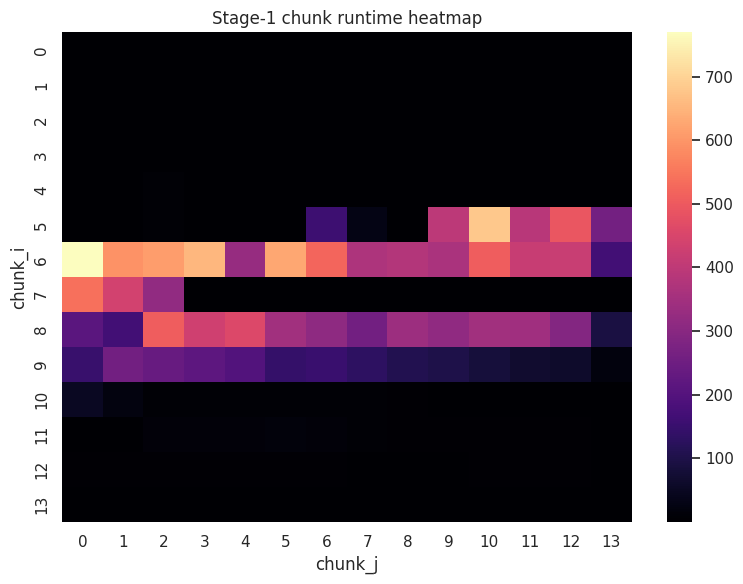

In [9]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

trial_dir = Path("/home/ijain/Clean_parflex/runtime_results/results_profiling/parflex_gpu_P80000_L6000_trial1")
df = pd.read_csv(trial_dir / "chunk_flexdtw.csv")
df = df[df["chunk_i"] != "warmup"].copy()
df["chunk_i"] = df["chunk_i"].astype(int)
df["chunk_j"] = df["chunk_j"].astype(int)
df["elapsed_seconds"] = pd.to_numeric(df["elapsed_seconds"], errors="coerce")

pivot = df.pivot(index="chunk_i", columns="chunk_j", values="elapsed_seconds")
plt.figure(figsize=(8,6))
sns.heatmap(pivot, cmap="magma")
plt.title("Stage-1 chunk runtime heatmap")
plt.xlabel("chunk_j")
plt.ylabel("chunk_i")
plt.tight_layout()
plt.show()